# F2.2 — Limpieza y transformación del conjunto de datos

**Proyecto Transversal MCDI500 — Grupo 8 — Universidad Andrés Bello**
Módulo: Programación para la Ciencia de Datos · Fase 2

---

## Propósito de este notebook

Implementar el pipeline de preprocesamiento que convierte el archivo crudo
`Ponds data.csv` en un dataset temporal limpio, con tipos correctos y listo para las
fases siguientes. Cada etapa responde a un hallazgo documentado en
`F2_01_Obtencion_Exploracion.ipynb`.

## Principios del pipeline

1. **Orden fijo.** Las etapas no son intercambiables; la clase `PipelineLimpieza`
   (`src/ponds/limpieza.py`) garantiza la secuencia.
2. **Evidencia antes → después.** Cada etapa registra filas y nulos antes y después
   en una bitácora. El efecto de la limpieza se demuestra con datos, no se afirma.
3. **No inventar información.** No se reconstruyen horas faltantes ni se rellenan
   huecos largos: donde no hubo medición, el dataset lo dice.
4. **Corregir fallos, conservar eventos.** Un valor físicamente imposible es un fallo
   de instrumento y se anula; un valor extremo pero posible es información y se conserva.

## Etapas

| # | Etapa | Hallazgo que la motiva |
|---|---|---|
| 1 | Normalizar nombres de columnas | Nombres con unidades y símbolos |
| 2 | Unificar centinelas de nulo | H-03 `#VALUE!` y `'NaN'` como texto |
| 3 | Eliminar filas completamente vacías | H-02 38 filas fantasma |
| 4 | Normalizar identificador de estanque | H-04 capitalización inconsistente |
| 5 | Convertir variables a numérico | H-01 columnas como `object` |
| 6 | Construir timestamp | H-07 fecha y hora separadas, 51 sin hora |
| 7 | Eliminar duplicados | H-05 |
| 8 | Anular valores físicamente imposibles | H-06 temperaturas de 0 °C |
| 9 | Regularizar a frecuencia de 20 min | H-08, H-09 interrupciones del registro |
| 10 | Interpolar huecos cortos (≤ 1 h) | H-09 |
| 11 | Derivar variables de calendario | Transformación para análisis temporal |
| 12 | Ordenar y fijar esquema final | — |

Después del pipeline se aplica el **escalamiento** de variables en una copia aparte.

---
## 1. Configuración del entorno

In [1]:
import sys
from pathlib import Path


def raiz_proyecto() -> Path:
    """Localiza la raiz del repositorio a partir del directorio de trabajo."""
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / "src" / "ponds").is_dir():
            return base
    raise RuntimeError(
        "No se encontro 'src/ponds'. Ejecute el notebook dentro del repositorio."
    )


RAIZ = raiz_proyecto()
if str(RAIZ / "src") not in sys.path:
    sys.path.insert(0, str(RAIZ / "src"))

import platform

import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
from IPython.display import Image, display

from ponds import rutas, io_datos, perfilado, limpieza, temporal, graficos

rutas.asegurar_directorios()
graficos.aplicar_estilo()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

print(f"Python {platform.python_version()} | numpy {np.__version__} | pandas {pd.__version__} "
      f"| matplotlib {matplotlib.__version__} | seaborn {sns.__version__}")
print("Raiz del proyecto:", RAIZ)

Python 3.10.11 | numpy 2.1.0 | pandas 2.2.2 | matplotlib 3.9.2 | seaborn 0.13.2
Raiz del proyecto: C:\Users\mcidf\Documents\proyecto-ponds


In [2]:
df_crudo = io_datos.cargar_crudo()
print(f"Dataset crudo: {df_crudo.shape[0]:,} filas x {df_crudo.shape[1]} columnas")
print("SHA-256:", io_datos.calcular_sha256(rutas.DIR_CRUDO / rutas.ARCHIVO_CRUDO))

# El pipeline se ejecuta etapa por etapa para mostrar el efecto de cada una.
# Con verboso=True cada etapa imprime su linea de bitacora.
pipe = limpieza.PipelineLimpieza(df_crudo, verboso=True)

Dataset crudo: 74,796 filas x 11 columnas


SHA-256: 101523d7f3e99749afcaa1a37c5ce0d0d4d3f109c86a1b47d0942b01e2c92c71


---
## 2. Ejecución del pipeline, etapa por etapa

### Etapa 1 — Normalizar nombres de columnas

**Qué hace.** Renombra las columnas a *snake_case* en español: `NITRATE(PPM)` pasa a
`nitrato`, `AMMONIA(mg/l)` a `amonio`, etc.

**Por qué.** Los paréntesis y barras obligan a escribir `df["AMMONIA(mg/l)"]` en todo el
código, lo que multiplica los errores de tipeo. Las unidades no se pierden: quedan
documentadas en `rutas.UNIDADES`.

In [3]:
columnas_antes = list(pipe.df.columns)
pipe.normalizar_nombres()

pd.DataFrame({"antes": columnas_antes, "despues": list(pipe.df.columns)})

[ 1] Normalizar nombres de columnas             filas  74796 ->  74796 (+0) | nulos   498 ->   498 | 9 columnas renombradas


,antes,despues
0,station,estanque
1,Date,Date
2,Time,Time
3,NITRATE(PPM),nitrato
4,PH,ph
5,AMMONIA(mg/l),amonio
6,TEMP,temperatura
7,DO,oxigeno_disuelto
8,TURBIDITY,turbidez
9,MANGANESE(mg/l),manganeso


### Etapa 2 — Unificar centinelas de nulo

**Qué hace.** Reemplaza por `NaN` las cadenas que representan ausencia de dato:
`#VALUE!` (error de Excel) y `'NaN'` escrito como texto.

**Por qué.** pandas no reconoce esas cadenas como ausentes. Si se dejaran, la
conversión a número de la etapa 5 las anularía igualmente, pero sin dejar registro
de cuántas eran ni dónde estaban. Hacerlo en una etapa propia deja la operación
cuantificada.

In [4]:
CENTINELAS_VISTOS = ["#VALUE!", "NaN"]
antes = pipe.df.isin(CENTINELAS_VISTOS).sum()

pipe.normalizar_centinelas()

despues = pipe.df.isin(CENTINELAS_VISTOS).sum()
evidencia = pd.DataFrame({"centinelas_antes": antes, "centinelas_despues": despues})
evidencia[evidencia["centinelas_antes"] > 0]

[ 2] Unificar centinelas de nulo                filas  74796 ->  74796 (+0) | nulos   498 ->   518 | 'NaN' x7, '#VALUE!' x13


,centinelas_antes,centinelas_despues
nitrato,6,0
ph,2,0
oxigeno_disuelto,6,0
manganeso,6,0


### Etapa 3 — Eliminar filas completamente vacías

**Qué hace.** Elimina las filas en las que todas las columnas son nulas.

**Por qué.** Son artefactos de la exportación (H-02) y no contienen información. Es la
única eliminación de filas sin ninguna pérdida de datos.

In [5]:
pipe.eliminar_filas_vacias()

assert not pipe.df.isna().all(axis=1).any(), "Quedan filas completamente vacias"
print("Verificado: no quedan filas completamente vacias.")

[ 3] Eliminar filas completamente vacias        filas  74796 ->  74758 (-38) | nulos   518 ->   100 | 38 filas fantasma
Verificado: no quedan filas completamente vacias.


### Etapa 4 — Normalizar identificador de estanque

**Qué hace.** Pasa `station` a minúsculas sin espacios y lo convierte a tipo `category`.

**Por qué.** Unifica `station1` / `Station2` / `Station3` (H-04). El tipo `category`
ocupa menos memoria que texto y deja explícito que la variable tiene sólo tres niveles.

In [6]:
antes = pipe.df["estanque"].value_counts().rename("antes")
pipe.normalizar_estanque()
despues = pipe.df["estanque"].value_counts().rename("despues")

pd.concat([antes, despues], axis=1)

[ 4] Normalizar identificador de estanque       filas  74758 ->  74758 (+0) | nulos   100 ->   100 | ['Station2', 'Station3', 'station1'] -> ['station1', 'station2', 'station3']


,antes,despues
estanque,,
Station2,25498.0,NaN
Station3,25461.0,NaN
station1,23799.0,23799.0
station2,NaN,25498.0
station3,NaN,25461.0


### Etapa 5 — Convertir variables a numérico (*casting*)

**Qué hace.** Convierte las siete variables medidas a `float64` y la etiqueta de la
fuente a entero anulable `Int8`.

**Por qué.** Sin esta conversión no es posible ningún cálculo. Se usa
`errors="coerce"`, que transforma en `NaN` lo que no sea número, y se cuenta cuántos
valores se pierden. **El conteo esperado es cero**: si la etapa 2 capturó todos los
centinelas, no debería quedar nada no convertible. Un valor distinto de cero
revelaría una codificación de nulo no detectada en la exploración.

In [7]:
tipos_antes = pipe.df.dtypes.astype(str)
pipe.convertir_tipos()
tipos_despues = pipe.df.dtypes.astype(str)

assert all(pd.api.types.is_float_dtype(pipe.df[c]) for c in rutas.VARIABLES)
pd.DataFrame({"dtype_antes": tipos_antes, "dtype_despues": tipos_despues})

[ 5] Convertir variables a numerico             filas  74758 ->  74758 (+0) | nulos   100 ->   100 | 0 celdas no convertibles -> NaN


,dtype_antes,dtype_despues
estanque,category,category
Date,object,object
Time,object,object
nitrato,object,float64
ph,object,float64
amonio,object,float64
temperatura,object,float64
oxigeno_disuelto,object,float64
turbidez,object,float64
manganeso,object,float64


### Etapa 6 — Construir la marca temporal

**Qué hace.** Combina `Date` y `Time` en una columna `timestamp` de tipo `datetime64`,
con formato declarado `%d-%m-%Y %H:%M:%S`, y descarta las filas sin instante válido.

**Por qué.** El eje temporal es la columna vertebral del dataset. El formato se declara
explícitamente para que `01-02-2022` se lea siempre como 1 de febrero. Las 51 filas
sin hora se descartan porque reconstruir la hora sería inventar una medición (H-07).

In [8]:
pipe.construir_eje_temporal()

assert pd.api.types.is_datetime64_any_dtype(pipe.df["timestamp"])
assert pipe.df["timestamp"].notna().all()
pipe.df[["timestamp", "estanque", "temperatura", "oxigeno_disuelto"]].head()

[ 6] Construir timestamp y descartar sin fecha/hora filas  74758 ->  74707 (-51) | nulos   100 ->    49 | 51 filas sin instante valido


,timestamp,estanque,temperatura,oxigeno_disuelto
0,2022-02-01 08:00:00,station1,23.20,11.6
1,2022-02-01 08:20:00,station1,23.41,10.5
2,2022-02-01 08:40:00,station1,23.63,10.3
3,2022-02-01 09:00:00,station1,23.64,9.4
4,2022-02-01 09:20:00,station1,23.81,8.8


### Etapa 7 — Eliminar duplicados

**Qué hace.** Elimina duplicados exactos y, después, duplicados por la clave
`(estanque, timestamp)`, conservando el primer registro.

**Por qué.** Cada estanque puede tener una sola lectura por instante. **El resultado
esperado es cero duplicados**: la exploración (H-05) mostró que todos los duplicados
del archivo crudo provenían de filas vacías o sin hora, ya eliminadas. La etapa se
mantiene igualmente como salvaguarda: si en el futuro el archivo cambia, el pipeline
no deja pasar un duplicado.

In [9]:
pipe.eliminar_duplicados()
assert not pipe.df.duplicated(subset=["estanque", "timestamp"]).any()
print("Verificado: la clave (estanque, timestamp) es unica.")

[ 7] Eliminar duplicados                        filas  74707 ->  74707 (+0) | nulos    49 ->    49 | 0 exactos + 0 por ('estanque', 'timestamp')
Verificado: la clave (estanque, timestamp) es unica.


### Etapa 8 — Anular valores físicamente imposibles

**Qué hace.** Convierte en `NaN` los valores fuera del rango que el instrumento puede
medir (`rutas.RANGOS_FISICOS`), sin eliminar la fila.

**Por qué.** Las temperaturas de 0,0 °C de la madrugada del 27-02-2022 (H-06) son un
fallo de sensor, no una medición. Se anula sólo el valor defectuoso: el resto de
variables de esa lectura sigue siendo válido.

Los rangos físicos son deliberadamente amplios. **No se recorta por rango
operacional**: un oxígeno disuelto bajo o un amonio alto son eventos reales de mala
calidad del agua y deben conservarse.

In [10]:
pd.DataFrame(rutas.RANGOS_FISICOS, index=["minimo_fisico", "maximo_fisico"]).T

,minimo_fisico,maximo_fisico
nitrato,0.0,500.0
ph,0.0,14.0
amonio,0.0,10.0
temperatura,5.0,50.0
oxigeno_disuelto,0.0,30.0
turbidez,0.0,1000.0
manganeso,0.0,10.0


In [11]:
t_min = rutas.RANGOS_FISICOS["temperatura"][0]
casos = pipe.df.loc[pipe.df["temperatura"] < t_min, ["timestamp", "estanque", "temperatura", "ph", "oxigeno_disuelto"]]
indices = casos.index
print(f"Lecturas con temperatura bajo {t_min} C antes de la etapa: {len(casos)}")

pipe.anular_fallos_de_sensor()

despues = pipe.df.loc[indices, ["timestamp", "estanque", "temperatura", "ph", "oxigeno_disuelto"]]
print(f"Temperatura minima tras la etapa: {pipe.df['temperatura'].min():.2f} C")
print("Las filas se conservan; solo la temperatura queda nula:")
despues.head(6)

Lecturas con temperatura bajo 5.0 C antes de la etapa: 12
[ 8] Anular valores fisicamente imposibles      filas  74707 ->  74707 (+0) | nulos    49 ->    61 | 12 valores anulados (temperatura=12)
Temperatura minima tras la etapa: 14.50 C
Las filas se conservan; solo la temperatura queda nula:


,timestamp,estanque,temperatura,ph,oxigeno_disuelto
25717,2022-02-27 05:00:00,station2,NaN,7.3876,2.12058
25718,2022-02-27 05:20:00,station2,NaN,8.0960,0.20196
25719,2022-02-27 05:40:00,station2,NaN,8.7032,1.51470
25720,2022-02-27 06:00:00,station2,NaN,8.9056,1.00980
25721,2022-02-27 06:20:00,station2,NaN,7.5900,1.11078
25722,2022-02-27 06:40:00,station2,NaN,7.9948,2.22156


### Etapa 9 — Regularizar a la frecuencia nominal de 20 minutos

**Qué hace.** Reindexa cada estanque a una rejilla regular de 20 minutos entre su primera
y su última lectura. Los instantes sin medición aparecen como filas con valores nulos,
marcadas con `fila_imputada = True`.

**Por qué.** Un hueco implícito (una fila que no existe) no se puede contar ni tratar.
Al hacerlo explícito, las interrupciones del registro (H-09) quedan visibles y la
serie pasa a tener paso constante, requisito de los métodos de series de tiempo de
las fases siguientes. La marca `fila_imputada` permite distinguir siempre qué filas
son medición real y cuáles creó la rejilla.

In [12]:
pipe.regularizar_frecuencia()

(
    pipe.df.groupby("estanque", observed=True)["fila_imputada"]
    .agg(filas_totales="size", filas_creadas_por_rejilla="sum")
)

[ 9] Regularizar a frecuencia nominal           filas  74707 ->  74854 (+147) | nulos    61 ->  1237 | 147 instantes sin medicion hechos explicitos


,filas_totales,filas_creadas_por_rejilla
estanque,,
station1,23832,50
station2,25560,79
station3,25462,18


### Etapa 10 — Tratar valores ausentes

**Qué hace.** Interpola linealmente en el tiempo, **por estanque**, los huecos de hasta
tres lecturas consecutivas (1 hora). Los huecos más largos se conservan como `NaN`.

**Por qué esta estrategia y no otra:**

| Alternativa | Motivo del descarte |
|---|---|
| Imputar con la media global | Borra la variación diaria y estacional, que es el objeto del proyecto |
| Eliminar filas con algún nulo | Rompe la rejilla regular construida en la etapa 9 |
| Interpolar todos los huecos | En un hueco de 20 horas inventaría una recta donde pudo haber un evento |
| **Interpolar sólo huecos ≤ 1 h** | **Respeta la inercia física de las variables en escalas cortas** |

La interpolación se hace por estanque para no mezclar el final de una serie con el
inicio de la siguiente, y nunca extrapola antes de la primera lectura ni después de
la última.

In [13]:
estado_previo = pipe.df[["estanque", "timestamp"] + rutas.VARIABLES].copy()
nulos_antes = estado_previo[rutas.VARIABLES].isna().sum()

pipe.tratar_nulos()

nulos_despues = pipe.df[rutas.VARIABLES].isna().sum()
pd.DataFrame(
    {
        "nulos_antes": nulos_antes,
        "valores_interpolados": nulos_antes - nulos_despues,
        "nulos_conservados": nulos_despues,
    }
)

[10] Interpolar huecos cortos (max 1 hora)      filas  74854 ->  74854 (+0) | nulos  1237 ->  1168 | 69 valores imputados, 1021 huecos largos conservados


,nulos_antes,valores_interpolados,nulos_conservados
nitrato,153,13,140
ph,149,9,140
amonio,147,7,140
temperatura,165,7,158
oxigeno_disuelto,157,13,144
turbidez,147,7,140
manganeso,172,13,159


**Ejemplo de hueco corto interpolado.** Se muestra la temperatura alrededor del primer
valor imputado, antes y después de la etapa.

In [14]:
comparacion = estado_previo[["estanque", "timestamp", "temperatura"]].merge(
    pipe.df[["estanque", "timestamp", "temperatura", "fila_imputada"]],
    on=["estanque", "timestamp"],
    suffixes=("_antes", "_despues"),
)
imputados = comparacion[comparacion["temperatura_antes"].isna() & comparacion["temperatura_despues"].notna()]
print(f"Valores de temperatura interpolados: {len(imputados)}")

primero = imputados.iloc[0]
ventana = comparacion[
    (comparacion["estanque"] == primero["estanque"])
    & comparacion["timestamp"].between(
        primero["timestamp"] - pd.Timedelta("80min"), primero["timestamp"] + pd.Timedelta("80min")
    )
]
ventana

Valores de temperatura interpolados: 7


,estanque,timestamp,temperatura_antes,temperatura_despues,fila_imputada
18,station1,2022-02-01 06:00:00,21.72,21.72,False
19,station1,2022-02-01 06:20:00,21.78,21.78,False
20,station1,2022-02-01 06:40:00,21.94,21.94,False
21,station1,2022-02-01 07:00:00,22.03,22.03,False
22,station1,2022-02-01 07:20:00,NaN,22.42,True
23,station1,2022-02-01 07:40:00,NaN,22.81,True
24,station1,2022-02-01 08:00:00,23.20,23.20,False
25,station1,2022-02-01 08:20:00,23.41,23.41,False
26,station1,2022-02-01 08:40:00,23.63,23.63,False


**Ejemplo de hueco largo conservado.** Se localiza la racha de nulos más larga y se
comprueba que sigue vacía.

In [15]:
rachas = (
    pipe.df.groupby("estanque", observed=True)["temperatura"]
    .transform(temporal.largo_rachas_nulas)
)
mas_larga = rachas.max()
fila = pipe.df.loc[rachas.idxmax(), ["estanque", "timestamp"]]
print(f"Hueco mas largo en temperatura: {mas_larga} lecturas "
      f"({mas_larga * rutas.MINUTOS_NOMINALES / 60:.1f} h), estanque {fila['estanque']}")

assert mas_larga > rutas.MAX_HUECOS_INTERPOLABLES
pipe.df.loc[rachas.idxmax() - 1 : rachas.idxmax() + 2, ["estanque", "timestamp", "temperatura", "fila_imputada"]]

Hueco mas largo en temperatura: 60 lecturas (20.0 h), estanque station2


,estanque,timestamp,temperatura,fila_imputada
49330,station2,2023-01-21 03:20:00,29.6984,False
49331,station2,2023-01-21 03:40:00,NaN,True
49332,station2,2023-01-21 04:00:00,NaN,True
49333,station2,2023-01-21 04:20:00,NaN,True


### Etapa 11 — Derivar variables de calendario

**Qué hace.** Añade año, mes, día, hora, minuto, día de la semana, año-mes, fecha,
estación del año y franja horaria, todas derivadas de `timestamp`.

**Por qué.** No aportan información nueva, pero dejan el dataset listo para agrupar y
graficar por periodo sin repetir la extracción en cada notebook. La estación del año
sigue el calendario climático de la India (invierno, verano, monzón, post-monzón),
ya que los estanques están en Andhra Pradesh.

In [16]:
pipe.derivar_variables()
pipe.df[["timestamp", "anio", "mes", "hora", "nombre_dia", "anio_mes", "estacion_anio", "franja_horaria"]].head()

[11] Derivar variables de calendario            filas  74854 ->  74854 (+0) | nulos  1168 ->  1168 | 11 variables anadidas: anio, mes, dia, hora, minuto, dia_semana, nombre_dia, anio_mes, fecha, estacion_anio, franja_horaria


,timestamp,anio,mes,hora,nombre_dia,anio_mes,estacion_anio,franja_horaria
0,2022-02-01 00:00:00,2022,2,0,Tuesday,2022-02,Invierno,Madrugada (00-05)
1,2022-02-01 00:20:00,2022,2,0,Tuesday,2022-02,Invierno,Madrugada (00-05)
2,2022-02-01 00:40:00,2022,2,0,Tuesday,2022-02,Invierno,Madrugada (00-05)
3,2022-02-01 01:00:00,2022,2,1,Tuesday,2022-02,Invierno,Madrugada (00-05)
4,2022-02-01 01:20:00,2022,2,1,Tuesday,2022-02,Invierno,Madrugada (00-05)


### Etapa 12 — Ordenar y fijar el esquema final

In [17]:
pipe.ordenar_y_finalizar()
df_limpio = pipe.df

df_limpio.info()

[12] Ordenar por estanque e instante            filas  74854 ->  74854 (+0) | nulos  1168 ->  1168 | 22 columnas finales
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74854 entries, 0 to 74853
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         74854 non-null  datetime64[ns]
 1   estanque          74854 non-null  category      
 2   nitrato           74714 non-null  float64       
 3   ph                74714 non-null  float64       
 4   amonio            74714 non-null  float64       
 5   temperatura       74696 non-null  float64       
 6   oxigeno_disuelto  74710 non-null  float64       
 7   turbidez          74714 non-null  float64       
 8   manganeso         74695 non-null  float64       
 9   anio              74854 non-null  Int16         
 10  mes               74854 non-null  Int8          
 11  dia               74854 non-null  Int8          
 12  hora     

---
## 3. Bitácora del pipeline

Registro completo de las doce etapas. Es la evidencia de trazabilidad del
preprocesamiento: cada fila indica qué hizo la etapa y cuál fue su efecto medible.

In [18]:
pipe.bitacora()

,n,etapa,filas_antes,filas_despues,delta_filas,nulos_antes,nulos_despues,detalle
0,1,Normalizar nombres de columnas,74796,74796,0,498,498,9 columnas renombradas
1,2,Unificar centinelas de nulo,74796,74796,0,498,518,"'NaN' x7, '#VALUE!' x13"
2,3,Eliminar filas completamente vacias,74796,74758,-38,518,100,38 filas fantasma
3,4,Normalizar identificador de estanque,74758,74758,0,100,100,"['Station2', 'Station3', 'station1'] -> ['stat..."
4,5,Convertir variables a numerico,74758,74758,0,100,100,0 celdas no convertibles -> NaN
5,6,Construir timestamp y descartar sin fecha/hora,74758,74707,-51,100,49,51 filas sin instante valido
6,7,Eliminar duplicados,74707,74707,0,49,49,"0 exactos + 0 por ('estanque', 'timestamp')"
7,8,Anular valores fisicamente imposibles,74707,74707,0,49,61,12 valores anulados (temperatura=12)
8,9,Regularizar a frecuencia nominal,74707,74854,147,61,1237,147 instantes sin medicion hechos explicitos
9,10,Interpolar huecos cortos (max 1 hora),74854,74854,0,1237,1168,"69 valores imputados, 1021 huecos largos conse..."


In [19]:
pipe.resumen()

,estado,filas,columnas,nulos
0,crudo,74796,11,498
1,procesado,74854,22,1168


**Lectura de la bitácora.** El número de filas **aumenta** en la etapa 9 y el número de
nulos crece en ese punto: no es un error, es la rejilla haciendo explícitos los
instantes sin medición. La etapa 10 reduce después esos nulos a los huecos largos,
que representan menos del 0,2 % de las celdas. Las columnas pasan de 11 a 22 por el
timestamp, las variables de calendario y la marca `fila_imputada`.

In [20]:
perfilado.estadisticos(df_limpio)

,variable,count,mean,std,min,25%,50%,75%,max,asimetria,curtosis,n_nulos,unidad
0,nitrato,74714.0,38.6719,35.7525,0.0000,16.0000,27.5386,39.4919,153.3952,1.5567,1.4937,140,ppm
1,ph,74714.0,6.5430,1.1096,4.5001,5.7000,6.4000,7.3024,9.0068,0.3790,-0.6929,140,adimensional
2,amonio,74714.0,0.0962,0.1599,0.0010,0.0296,0.0448,0.1031,1.8720,5.2136,32.6821,140,mg/L
3,temperatura,74696.0,27.2306,5.9619,14.5004,22.9257,26.8200,30.4300,45.4995,0.6079,0.3384,158,grados Celsius
4,oxigeno_disuelto,74710.0,10.7572,5.5084,0.0000,6.5673,9.1000,14.9864,25.4976,0.6034,-0.5024,144,mg/L
5,turbidez,74714.0,31.5891,11.6295,10.2000,22.8626,30.0872,37.2686,82.0922,1.0151,1.1445,140,NTU
6,manganeso,74695.0,0.9807,0.7711,0.2000,0.5544,0.7057,0.9556,3.5762,1.7790,2.1712,159,mg/L


---
## 4. Escalamiento de variables

El dataset limpio se mantiene en **unidades físicas**, que son las interpretables. El
escalamiento se aplica en una **copia aparte** (`limpieza.escalar_variables`) destinada
al modelado de las fases siguientes, donde las diferencias de magnitud entre variables
(el nitrato llega a 150 ppm y el amonio no supera 2 mg/L) sesgarían los métodos
basados en distancias.

Se escala **por estanque**, porque cada uno tiene su propio nivel de base.

In [21]:
df_escalado = limpieza.escalar_variables(df_limpio, metodo="zscore")

# Tras un z-score, cada variable debe tener media ~0 y desviacion ~1 en cada estanque.
df_escalado.groupby("estanque", observed=True)[rutas.VARIABLES].agg(["mean", "std"]).round(3).T

estanque               station1  station2  station3
nitrato          mean      -0.0       0.0       0.0
                 std        1.0       1.0       1.0
ph               mean      -0.0       0.0       0.0
                 std        1.0       1.0       1.0
amonio           mean      -0.0       0.0       0.0
                 std        1.0       1.0       1.0
temperatura      mean      -0.0      -0.0      -0.0
                 std        1.0       1.0       1.0
oxigeno_disuelto mean      -0.0       0.0       0.0
                 std        1.0       1.0       1.0
turbidez         mean      -0.0      -0.0      -0.0
                 std        1.0       1.0       1.0
manganeso        mean       0.0      -0.0      -0.0
                 std        1.0       1.0       1.0

In [22]:
# Alternativa min-max: cada variable queda en el intervalo [0, 1].
df_minmax = limpieza.escalar_variables(df_limpio, metodo="minmax")
df_minmax[rutas.VARIABLES].agg(["min", "max"]).round(3)

,nitrato,ph,amonio,temperatura,oxigeno_disuelto,turbidez,manganeso
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0


Se adopta **z-score** como escalado de referencia para F3: es menos sensible que
min-max a un único valor extremo, que en min-max comprimiría el resto de la serie
contra un borde del intervalo.

---
## 5. Visualización de las series de tiempo limpias

Series agregadas a media diaria. Las líneas discontinuas indican el rango operacional
de referencia y se muestran sólo como contexto.

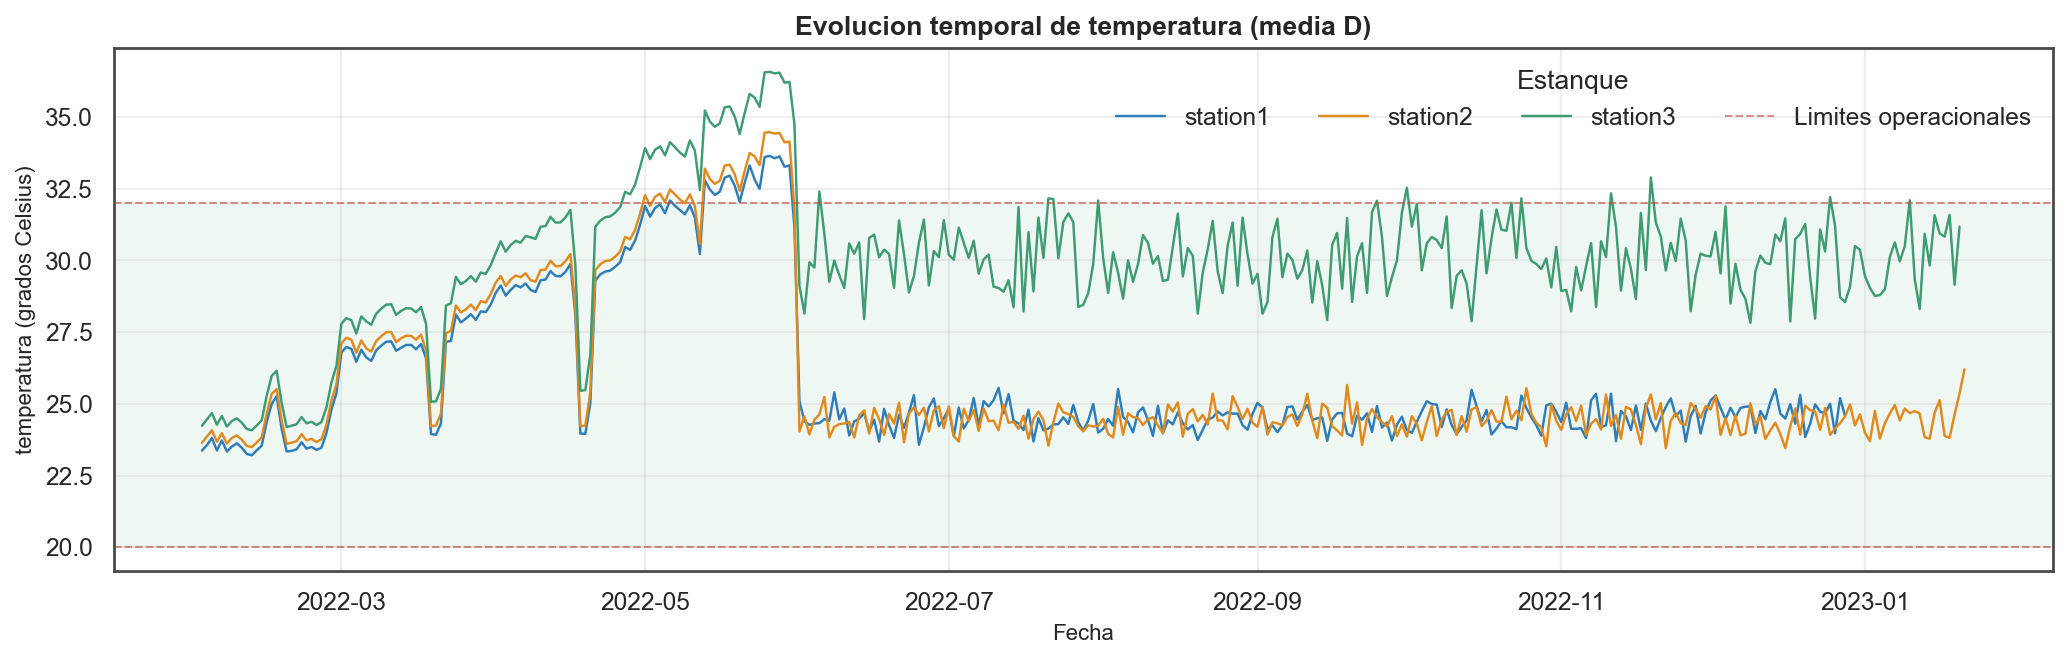

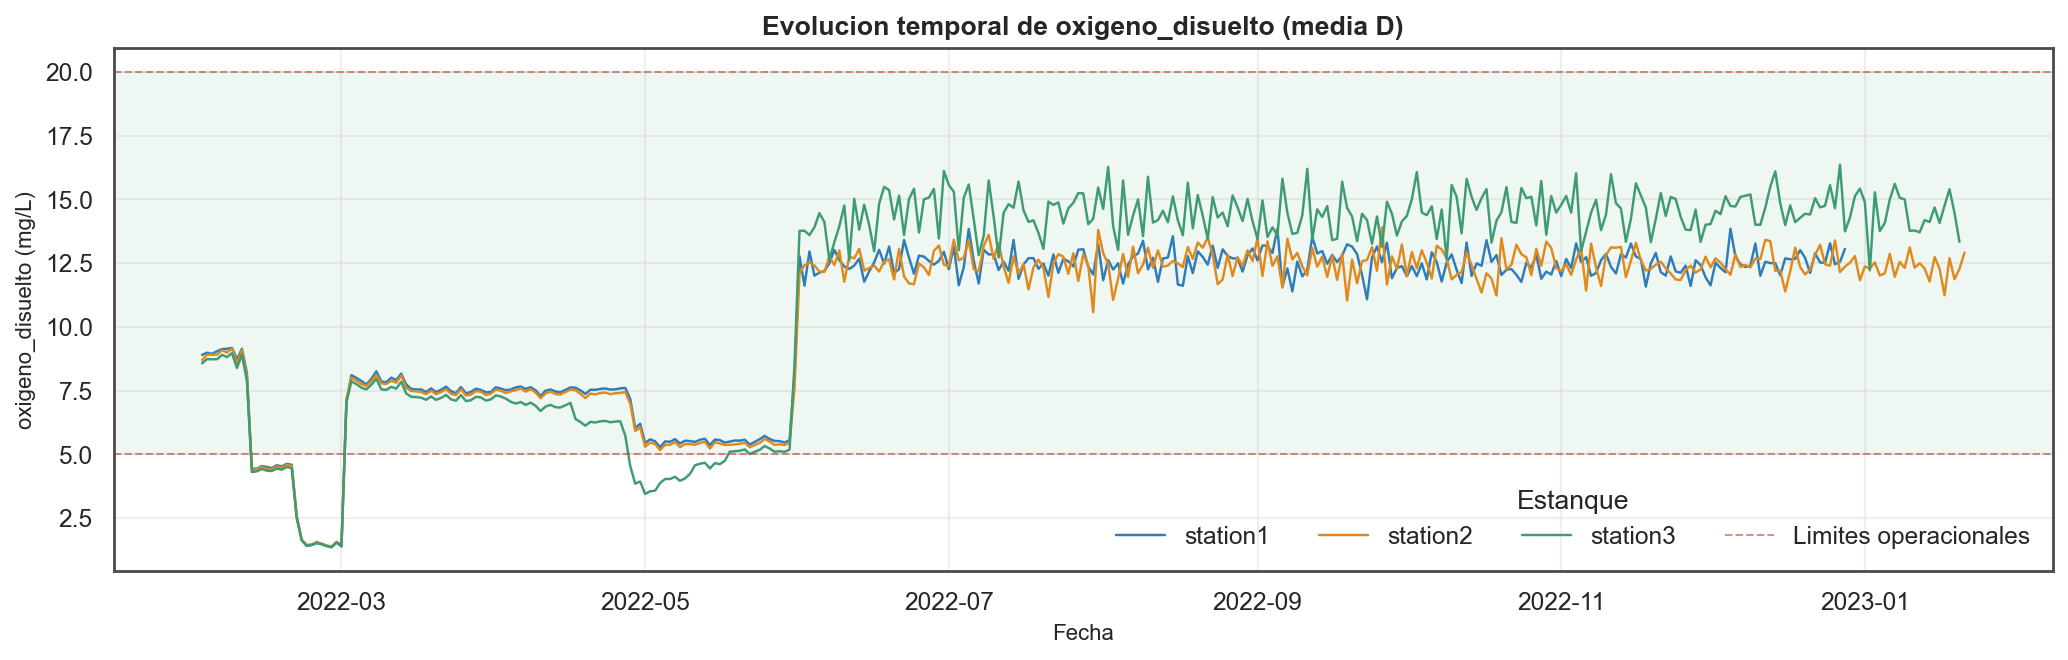

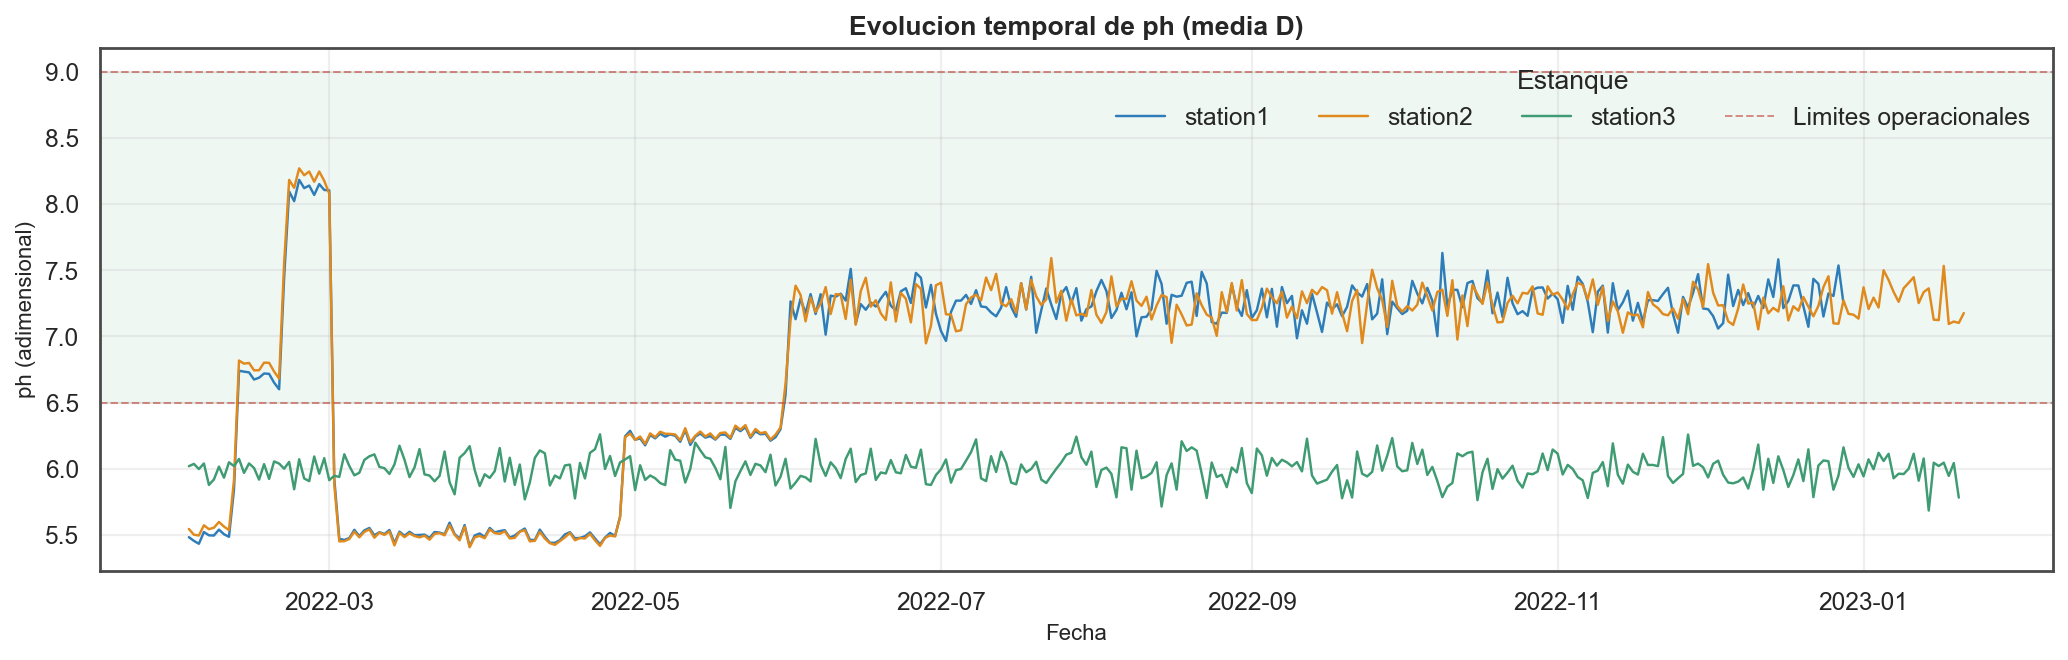

In [23]:
for variable in ["temperatura", "oxigeno_disuelto", "ph"]:
    ruta = graficos.serie_temporal(df_limpio, variable, nombre=f"f06_serie_{variable}_limpia")
    display(Image(filename=str(ruta)))

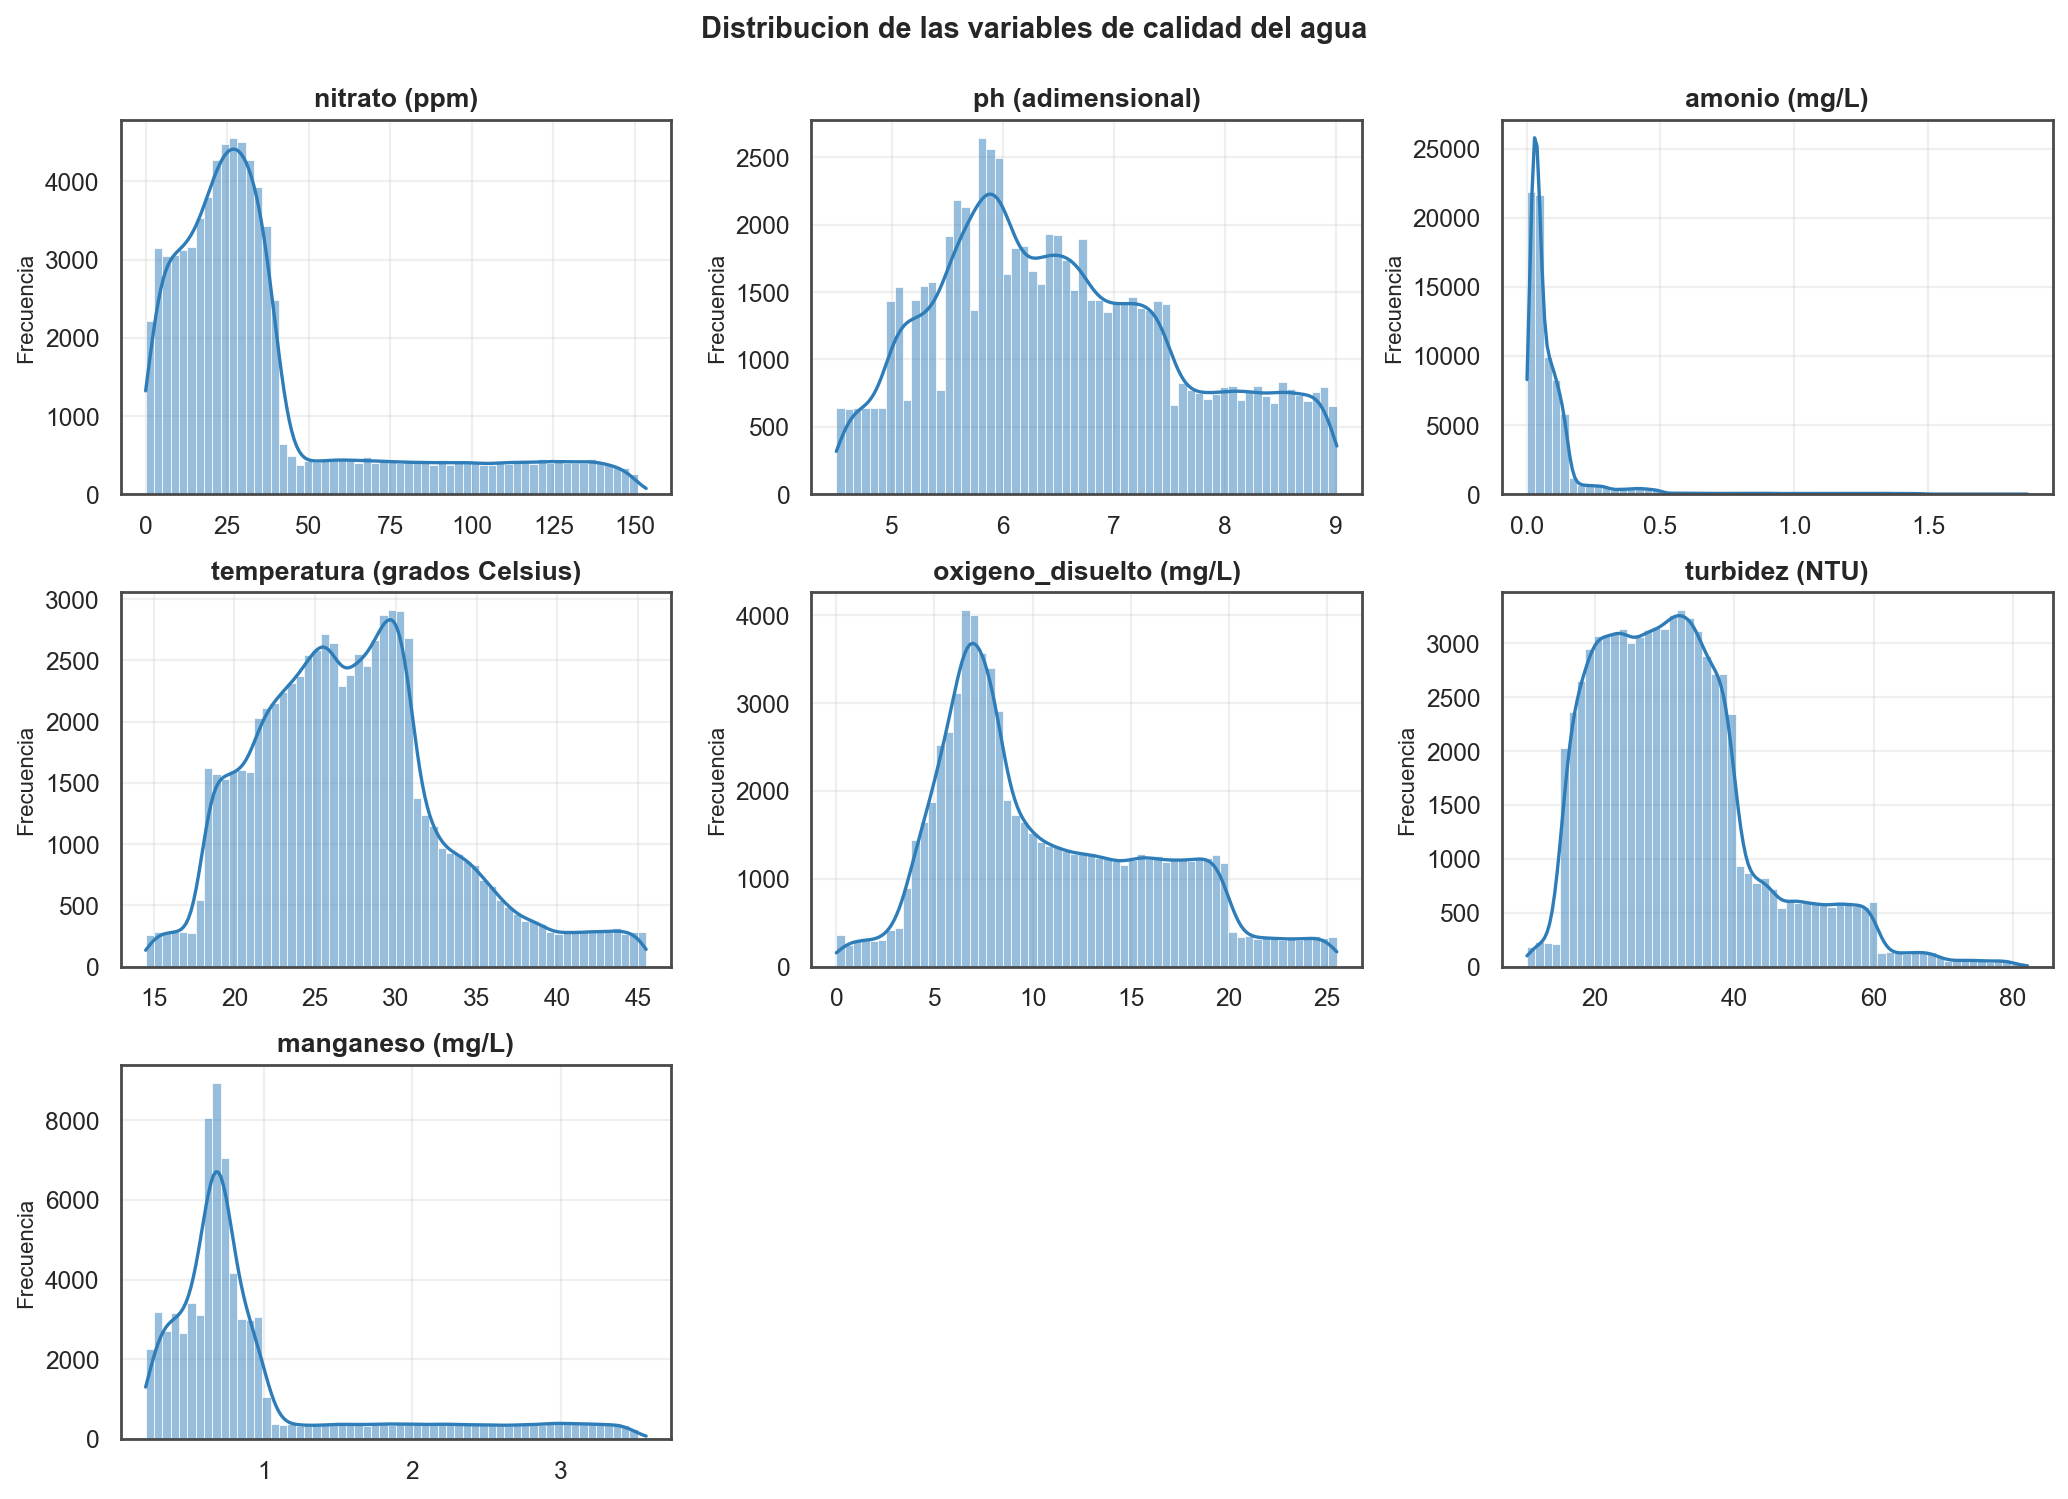

In [24]:
ruta = graficos.distribuciones(df_limpio, nombre="f07_distribuciones_limpio")
display(Image(filename=str(ruta)))

---
## 6. Exportación del dataset

Se guardan dos archivos en `data/processed/`:

- `ponds_limpio.csv` — dataset limpio en unidades físicas (producto principal de F2).
- `ponds_escalado.csv` — copia escalada con z-score por estanque, para F3.

Los CSV no conservan los tipos de dato, así que se comprueba que la recarga con
`io_datos.cargar_procesado` los restituye exactamente.

In [25]:
ruta_limpio = io_datos.guardar_procesado(df_limpio)
ruta_escalado = io_datos.guardar_procesado(df_escalado, "ponds_escalado.csv")

for r in (ruta_limpio, ruta_escalado):
    print(f"{r.relative_to(RAIZ)}  ({r.stat().st_size / 1e6:.1f} MB)")

recarga = io_datos.cargar_procesado()
assert recarga.shape == df_limpio.shape, "La recarga cambio las dimensiones"

tipos = pd.DataFrame({"original": df_limpio.dtypes.astype(str), "recargado": recarga.dtypes.astype(str)})
tipos["coincide"] = tipos["original"] == tipos["recargado"]
assert tipos.loc[tipos.index != "fecha", "coincide"].all(), tipos[~tipos["coincide"]]
tipos

data\processed\ponds_limpio.csv  (12.0 MB)
data\processed\ponds_escalado.csv  (18.2 MB)


,original,recargado,coincide
timestamp,datetime64[ns],datetime64[ns],True
estanque,category,category,True
nitrato,float64,float64,True
ph,float64,float64,True
amonio,float64,float64,True
temperatura,float64,float64,True
oxigeno_disuelto,float64,float64,True
turbidez,float64,float64,True
manganeso,float64,float64,True
anio,Int16,Int16,True


> La columna `fecha` es un objeto `date` de Python en memoria y texto al recargar; ambos
> se muestran como `object`. No afecta al análisis, que usa `timestamp`.

---
## 7. Conclusiones

1. El pipeline transforma 74.796 filas crudas con once columnas de texto en **74.854
   filas con 22 columnas tipadas**, sobre una rejilla temporal regular de 20 minutos
   por estanque.
2. Se eliminaron sólo registros sin información utilizable: 38 filas vacías y 51 sin
   hora. **Ninguna medición válida se descartó.**
3. Los doce valores de temperatura imposibles se anularon sin perder el resto de cada
   lectura.
4. Los huecos cortos se interpolaron y los largos se conservaron como nulos, marcados
   y contables.
5. El dataset se entrega en dos versiones: unidades físicas y escalado por estanque.

La verificación sistemática del resultado se realiza en
**`F2_03_Validacion.ipynb`**.